# Problems

1. Model will have a bias for majority value category.

2. It is difficult to detect as the accuracy value will be extremely high.Due to high accuracy we may think that the model is performing exceptionally well.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# Create a synthetic dataset with a larger imbalance
X, y = make_classification(
    n_samples=100000,  # total number of samples
    n_features=20,  # number of features
    n_informative=2,  # number of informative features
    n_redundant=10,  # number of redundant features
    n_clusters_per_class=1,  # number of clusters per class
    weights=[0.95, 0.05],  # class imbalance (95% majority, 5% minority)
    flip_y=0,  # label noise
    random_state=42  # reproducibility
)

In [3]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pd.Series(y_train).value_counts()

0    66515
1     3485
Name: count, dtype: int64

In [4]:
# Train a simple logistic regression model
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_report_str = classification_report(y_test, y_pred)

In [5]:
# Display results
print("Accuracy:", accuracy)

Accuracy: 0.9879333333333333


### Higher Accuracy may confuse us.

### Classifcation Report gives us the clear picture.

In [6]:
print("Classification Report:\n", classification_report_str)

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     28485
           1       1.00      0.76      0.86      1515

    accuracy                           0.99     30000
   macro avg       0.99      0.88      0.93     30000
weighted avg       0.99      0.99      0.99     30000



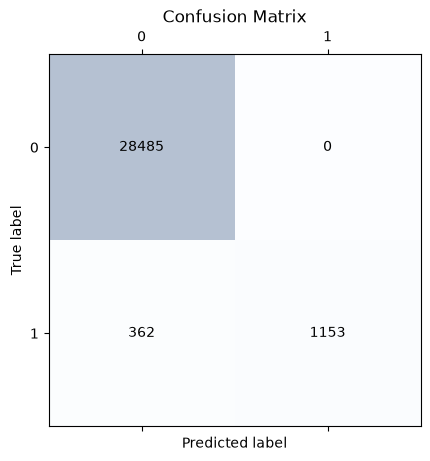

In [7]:
# Plotting confusion matrix
plt.matshow(confusion, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(x=j, y=i, s=confusion[i, j], ha='center', va='center')

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()